In [1]:
#------使用PLS模型-透射光谱-使用光谱预处理方法-融合RGB------#
#------储存路径代号：PLS_Fusion_01------#

In [ ]:
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
from utils.train_log import EvaluationMetricsLogger,PredictionSaver
from utils import datalodaer,model_trainer,preprocess,utils,ploter

import pandas as pd
import numpy as np
from datetime import datetime

# 设置全局字体为 "Times New Roman"
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 9         # 设置全局字体大小
plt.rcParams['axes.unicode_minus'] = False  # 设置支持负号显示
plt.rcParams['svg.fonttype'] = 'none'

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

series_path = '03-PLS-TS&RGB-Preprocessing'

In [3]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
labels_file = project_root / 'data/labels'
image_features_path = project_root / 'data/pictures/rgb_features.csv'
logger = EvaluationMetricsLogger()
saver = PredictionSaver()

加载现有日志文件: ../results/model_evaluation/evaluation_metrics_log.csv，包含 180 条记录
加载现有预测文件: ../results/model_evaluation/predictions_log.csv，包含 930 条预测记录


In [4]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

NO.1 [正在训练: PH | 预处理: Raw]========================
预测结果已保存OK
实验记录已保存: PH-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9116, 验证集 R²: 0.0000, 测试集 R²: 0.6974



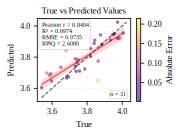

NO.2 [正在训练: PH | 预处理: Detrend]========================
预测结果已保存OK
实验记录已保存: PH-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8652, 验证集 R²: 0.0000, 测试集 R²: 0.8225



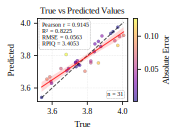

NO.3 [正在训练: PH | 预处理: SNV]========================
预测结果已保存OK
实验记录已保存: PH-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8741, 验证集 R²: 0.0000, 测试集 R²: 0.7832



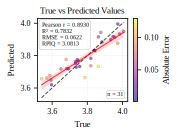

NO.4 [正在训练: PH | 预处理: MSC]========================
预测结果已保存OK
实验记录已保存: PH-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8461, 验证集 R²: 0.0000, 测试集 R²: 0.8368



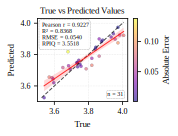

NO.5 [正在训练: PH | 预处理: SG_1]========================
预测结果已保存OK
实验记录已保存: PH-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8365, 验证集 R²: 0.0000, 测试集 R²: 0.7643



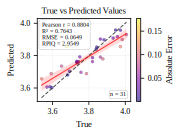

NO.6 [正在训练: PH | 预处理: SG_2]========================
预测结果已保存OK
实验记录已保存: PH-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8269, 验证集 R²: 0.0000, 测试集 R²: 0.7646



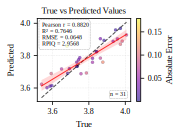

NO.7 [正在训练: GLU | 预处理: Raw]========================
预测结果已保存OK
实验记录已保存: GLU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.7966, 验证集 R²: 0.0000, 测试集 R²: 0.7377



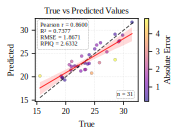

NO.8 [正在训练: GLU | 预处理: Detrend]========================
预测结果已保存OK
实验记录已保存: GLU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8448, 验证集 R²: 0.0000, 测试集 R²: 0.7601



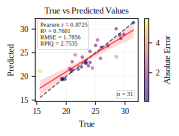

NO.9 [正在训练: GLU | 预处理: SNV]========================
预测结果已保存OK
实验记录已保存: GLU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8066, 验证集 R²: 0.0000, 测试集 R²: 0.7342



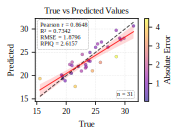

NO.10 [正在训练: GLU | 预处理: MSC]========================
预测结果已保存OK
实验记录已保存: GLU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8396, 验证集 R²: 0.0000, 测试集 R²: 0.7549



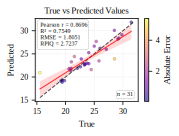

NO.11 [正在训练: GLU | 预处理: SG_1]========================
预测结果已保存OK
实验记录已保存: GLU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8551, 验证集 R²: 0.0000, 测试集 R²: 0.7836



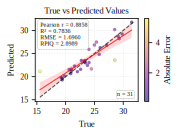

NO.12 [正在训练: GLU | 预处理: SG_2]========================
预测结果已保存OK
实验记录已保存: GLU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8473, 验证集 R²: 0.0000, 测试集 R²: 0.7728



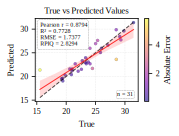

NO.13 [正在训练: 5-HMF | 预处理: Raw]========================
预测结果已保存OK
实验记录已保存: 5-HMF-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9568, 验证集 R²: 0.0000, 测试集 R²: 0.9514



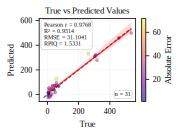

NO.14 [正在训练: 5-HMF | 预处理: Detrend]========================
预测结果已保存OK
实验记录已保存: 5-HMF-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9551, 验证集 R²: 0.0000, 测试集 R²: 0.9755



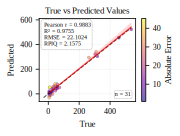

NO.15 [正在训练: 5-HMF | 预处理: SNV]========================
预测结果已保存OK
实验记录已保存: 5-HMF-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9572, 验证集 R²: 0.0000, 测试集 R²: 0.9787



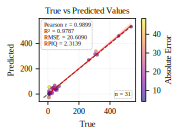

NO.16 [正在训练: 5-HMF | 预处理: MSC]========================
预测结果已保存OK
实验记录已保存: 5-HMF-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9504, 验证集 R²: 0.0000, 测试集 R²: 0.9760



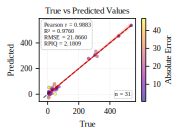

NO.17 [正在训练: 5-HMF | 预处理: SG_1]========================
预测结果已保存OK
实验记录已保存: 5-HMF-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9705, 验证集 R²: 0.0000, 测试集 R²: 0.9464



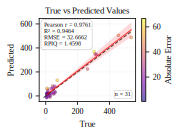

NO.18 [正在训练: 5-HMF | 预处理: SG_2]========================
预测结果已保存OK
实验记录已保存: 5-HMF-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9417, 验证集 R²: 0.0000, 测试集 R²: 0.9437



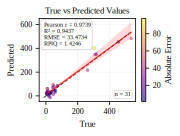

NO.19 [正在训练: Water | 预处理: Raw]========================
预测结果已保存OK
实验记录已保存: Water-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9854, 验证集 R²: 0.0000, 测试集 R²: 0.9951



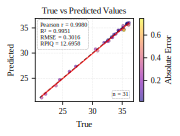

NO.20 [正在训练: Water | 预处理: Detrend]========================
预测结果已保存OK
实验记录已保存: Water-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9882, 验证集 R²: 0.0000, 测试集 R²: 0.9963



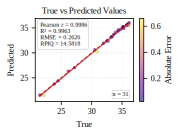

NO.21 [正在训练: Water | 预处理: SNV]========================
预测结果已保存OK
实验记录已保存: Water-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9892, 验证集 R²: 0.0000, 测试集 R²: 0.9928



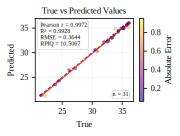

NO.22 [正在训练: Water | 预处理: MSC]========================
预测结果已保存OK
实验记录已保存: Water-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9892, 验证集 R²: 0.0000, 测试集 R²: 0.9934



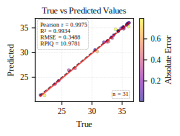

NO.23 [正在训练: Water | 预处理: SG_1]========================
预测结果已保存OK
实验记录已保存: Water-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9878, 验证集 R²: 0.0000, 测试集 R²: 0.9984



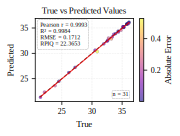

NO.24 [正在训练: Water | 预处理: SG_2]========================
预测结果已保存OK
实验记录已保存: Water-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.9879, 验证集 R²: 0.0000, 测试集 R²: 0.9966



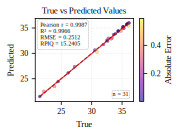

NO.25 [正在训练: FRU | 预处理: Raw]========================
预测结果已保存OK
实验记录已保存: FRU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.7352, 验证集 R²: 0.0000, 测试集 R²: 0.5905



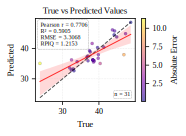

NO.26 [正在训练: FRU | 预处理: Detrend]========================
预测结果已保存OK
实验记录已保存: FRU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.7633, 验证集 R²: 0.0000, 测试集 R²: 0.6287



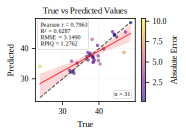

NO.27 [正在训练: FRU | 预处理: SNV]========================
预测结果已保存OK
实验记录已保存: FRU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.7256, 验证集 R²: 0.0000, 测试集 R²: 0.6055



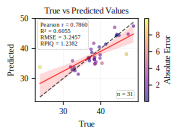

NO.28 [正在训练: FRU | 预处理: MSC]========================
预测结果已保存OK
实验记录已保存: FRU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.7445, 验证集 R²: 0.0000, 测试集 R²: 0.6258



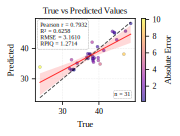

NO.29 [正在训练: FRU | 预处理: SG_1]========================
预测结果已保存OK
实验记录已保存: FRU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.7820, 验证集 R²: 0.0000, 测试集 R²: 0.5954



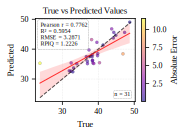

NO.30 [正在训练: FRU | 预处理: SG_2]========================
预测结果已保存OK
实验记录已保存: FRU-03-PLS-TS&RGB-Preprocessing
训练集 R²: 0.8003, 验证集 R²: 0.0000, 测试集 R²: 0.6226



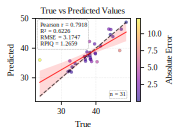

所有模型及预处理对比训练完成！


In [5]:
# 遍历所有 Label 文件
i = 0
for filename in os.listdir(labels_file):
    if filename.endswith(('.csv',)):
        label_path = os.path.join(labels_file, filename)
        label_name = os.path.splitext(filename)[0]

        # 读取并分割数据 (只需做一次)
        try:
            # 1. 加载、对齐数据，并划分数据集
            train_set, val_set, test_set = datalodaer.fused_data_split(spectra_path,image_features_path,label_path)

            # 2. 内部循环：遍历预处理方法
            for prep_name, prep_obj in preprocess_methods.items():
                i += 1
                print(f"NO.{i} [正在训练: {label_name} | 预处理: {prep_name}]========================")

                # =========================================
                # A. 数据融合处理 (关键步骤)
                # =========================================
                # 1. 光谱部分: 应用特定的预处理 (fit on train, transform all)
                spec_train_trans = prep_obj.fit_transform(train_set[0])
                spec_val_trans = prep_obj.transform(val_set[0])
                spec_test_trans = prep_obj.transform(test_set[0])

                # 2. 图像特征部分: (StandardScaler在PLS内进行)
                image_train_trans = train_set[1]
                image_val_trans = val_set[1]
                image_test_trans = test_set[1]

                # 3. 特征级融合 (Concatenation)
                X_train_fused = np.hstack([spec_train_trans, image_train_trans])
                X_val_fused = np.hstack([spec_val_trans, image_val_trans])
                X_test_fused = np.hstack([spec_test_trans, image_test_trans])

                # 4. 构建数据元组
                fused_train_set = (X_train_fused, train_set[2])
                fused_val_set = (X_val_fused, val_set[2])
                fused_test_set = (X_test_fused, test_set[2])

                # =========================================
                # B. 模型 1: PLS 回归
                # =========================================
                # 构造路径名，包含预处理信息
                model_name = series_path
                notes = f"PLS + 透射光谱&RGB + {prep_name} 预处理"

                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                # 构造路径名，包含预处理信息
                figure_name = f"Fig_{series_path}-({label_name}; {prep_name})_{timestamp}"

                # 训练PLS
                X2train = np.concatenate([fused_train_set[0], fused_val_set[0]], axis=0)
                y2train = np.concatenate([fused_train_set[1], fused_val_set[1]], axis=0)
                best_model, evaluation = model_trainer.tune_pls(X2train, y2train, prep_obj)

                y2train_pred = best_model.predict(X2train)
                y_test_pred = best_model.predict(fused_test_set[0])
                # 保存预测结果到csv文件
                results_df = pd.DataFrame({
                    'index': test_set[3],
                    'true_value': test_set[2],
                    'predicted_value': y_test_pred
                })
                results_df['label_name'] = label_name
                results_df['model_name'] = notes
                results_df['prediction_time'] = timestamp
                saver.save_prediction(results_df)
                
                train_r, train_rmse, train_r2, train_rpiq, train_mae = utils.evaluate_model(y2train, y2train_pred)
                test_r, test_rmse, test_r2, test_rpiq, test_mae = utils.evaluate_model(test_set[2], y_test_pred)

                # 创建当前实验的数据字典
                # 这里我们在 model_name 后加上预处理方式，以便在日志中区分
                metrics_data = {
                    'Timestamp': [timestamp,timestamp, timestamp],
                    'Experiment': [label_name,label_name, label_name],
                    'Model': [model_name,model_name, model_name],
                    'Dataset': ['Training','Validation', 'Test'],
                    'Pearson_r': [train_r,0, test_r],
                    'RMSE': [train_rmse,0, test_rmse],
                    'R2': [train_r2,0, test_r2],
                    'RPIQ': [train_rpiq,0, test_rpiq],
                    'MAE': [train_mae,0, test_mae],
                    'Notes': [notes,0, notes]
                }
                logger.log_metrics(metrics_data, model_name, label_name, parameters=evaluation)  # 记录日志
                ploter.correlation_scatter(6.5, 5, test_set[2], y_test_pred, figure_name)

        except Exception as e:
            print(f"执行失败: {filename} - 错误: {str(e)}")

print("所有模型及预处理对比训练完成！")